In [1]:
#box-model approach: inflow - outflow + sources - sinks

In [4]:
import numpy as np
import matplotlib.pyplot as plt

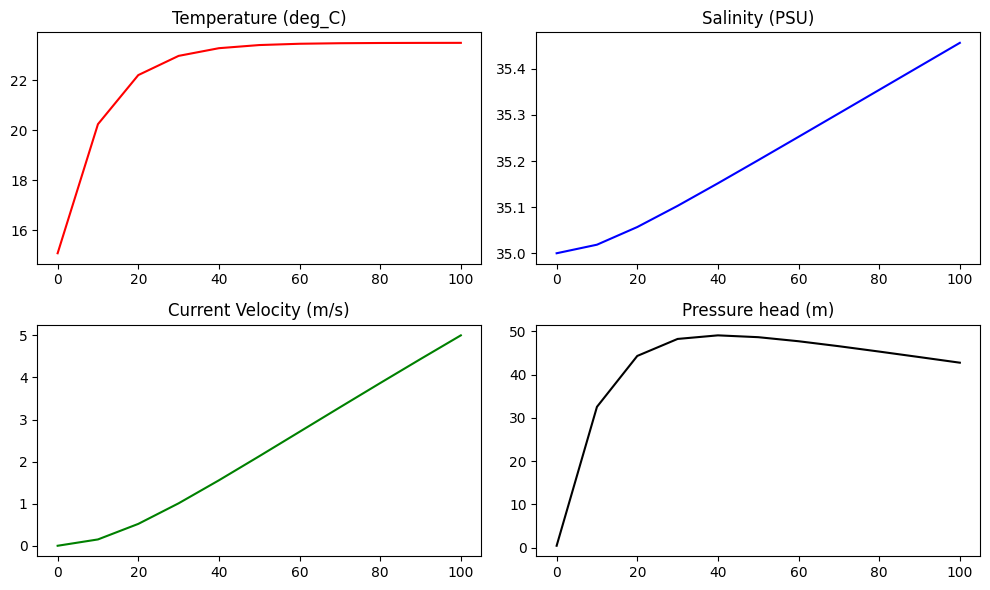

In [57]:
#setting the grid & physical constants
nx, ny = 50, 50 #corase grid
rho0, cp, g = 1025.0, 3985.0, 9.81 #density, specific heat capacity at constant P, gravity
solar_flux = 340.0 # W/m^2 = solar constant
dt = 86400 * 30    #1 month step
#constants for kooling
T_air = 15.0   #atmospheric equilibrium temperature (deg_C)
h_loss = 40.0  #heat loss coefficient (~40 W/m^2 per degree difference) IR cooling and evaporation
f = 1e-4  # Coriolis parameter (typical for mid-latitudes)

#bathymetry & boundaries
#basin that is shallower at the edges for coasts
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y)
bathymetry = 4000 * (1 - 0.5 * np.exp(-(X**2 + Y**2)/0.5))

#Mask for boundary represntation: 0 for land (edges), 1 for ocean
mask = np.ones((nx, ny))
mask[0,:] = mask[-1,:] = mask[:,0] = mask[:,-1] = 0

#initially the state is-
T = np.full((nx, ny), 15.0) #temp
S = np.full((nx, ny), 35.0) #salinity
U = np.zeros((nx, ny)) #momentum
V = np.zeros((nx, ny)) #momentum
history = {"T": [], "S": [], "U": [], "P": [], "years": []}

#simulation (10 decades)
for step in range(1201):
    #RADIATION AND COOLING = net flux = Gain (solar) - Loss (relaxation to air temperature)
    net_heat_flux = solar_flux - h_loss * (T - T_air)

    heat_change = (net_heat_flux * dt) / (rho0 * bathymetry * cp)
    T += heat_change * mask
    
    #CONSERVATION OF SALT = Simple evap-precip feedback
    S += 0.00005 * (T - 15) * mask
    
    #HYDROSTATIC PRESSURE = density * gravity * gepth
    rho = rho0 * (1 - 2e-4 * (T - 15) + 8e-4 * (S - 35))
    pressure = g * (rho - rho0) / rho0 * bathymetry
    
    #MOMENTUM with Coriolis
    dpdx, dpdy = np.gradient(pressure) #gradients in both directions
    
    #update U and V including the Coriolis term (f*V and -f*U)
    #1e-6 is existing damping factor
    U += (f * V - (1/rho0) * dpdx) * dt * 1e-6 * mask
    V += (-f * U - (1/rho0) * dpdy) * dt * 1e-6 * mask

    
    if step % 120 == 0:
        history["years"].append(step/12)
        history["T"].append(np.mean(T[mask==1]))
        history["S"].append(np.mean(S[mask==1]))
        history["U"].append(np.mean(np.abs(U[mask==1])))
        history["P"].append(np.mean(np.abs(pressure[mask==1])))

#plots~
fig, axs = plt.subplots(2, 2, figsize=(10, 6))
axs[0,0].plot(history["years"], history["T"], 'r'); axs[0,0].set_title("Temperature (deg_C)")
axs[0,1].plot(history["years"], history["S"], 'b'); axs[0,1].set_title("Salinity (PSU)")
axs[1,0].plot(history["years"], history["U"], 'g'); axs[1,0].set_title("Current Velocity (m/s)")
axs[1,1].plot(history["years"], history["P"], 'k'); axs[1,1].set_title("Pressure head (m)")
plt.tight_layout(); plt.show()
